# 🧮 The MMM as a Generative Model

> **The index of the math series. One equation to rule them all, then the priors, then a
> single prior draw simulated in pure NumPy.**
> This is notebook **00**. It frames *why* every other notebook exists: the framework's
> `BayesianMMM` is, at heart, a **generative story** for the weekly KPI. Write that story
> down as math, sample it once, and the whole pipeline — adstock, saturation, baseline,
> likelihood — falls out as the pieces you need to understand in detail.

A marketing-mix model answers a causal-flavored question — *"how much of my sales did each
channel cause, and what would another dollar buy?"* — but it answers it through a **forward
model**: a recipe that, given parameters $\theta$, *generates* a plausible KPI series. Fitting
the model is just running that recipe **backwards** (Bayesian inference) to find the $\theta$
that could have produced the data we actually saw.

This notebook is **pure NumPy + matplotlib** — no PyMC, no sampling. We will:

1. Write the **full additive linear predictor** $\mu_t$ and the **Normal likelihood**, defining every symbol.
2. Render the **exact priors** the framework places on each parameter, with one-line intuition.
3. Draw the **pipeline schematic**: raw spend $\to$ adstock $\to$ saturation $\to \times\beta \to$ sum with baseline $\to$ Normal draw.
4. **Simulate one draw from the prior** — sample every prior with NumPy, build a synthetic spend matrix, push it through the *real* framework transforms, and plot the resulting KPI with its additive decomposition.
5. Hand off to the rest of the series with a **roadmap**.

Every formula below is verified against `src/mmm_framework/model/base.py` (`_build_model`, lines 836–1030)
with `assert` statements — so "the notebook runs clean" *means* "the math is right."

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aurora import PALETTE, CHANNEL_COLORS   # brand colors for visual consistency
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

## 1. The generative equation

The framework first **standardizes** the KPI so all priors live on a common, unit-free scale:

$$
\tilde y_t \;=\; \frac{y_t - \bar y}{s_y},
\qquad \bar y = \text{mean}(y), \quad s_y = \text{std}(y).
$$

Everything downstream is modeled on $\tilde y_t$, then mapped back with $y_t = s_y\,\tilde y_t + \bar y$.

The heart of the model is a single **additive linear predictor** $\mu_t$ — the model's noiseless
expectation for the standardized KPI in period $t$:

$$
\boxed{\;
\mu_t \;=\; \underbrace{\text{intercept}}_{\text{baseline level}}
\;+\; \text{trend}_t
\;+\; \text{seasonality}_t
\;+\; \text{geo}_{[g]}
\;+\; \text{product}_{[p]}
\;+\; \underbrace{\text{media}_t}_{\text{the question}}
\;+\; \text{controls}_t
\;}
$$

The **media** term is where the marketing nonlinearity lives. It sums, over channels $c$, a coefficient
$\beta_c$ times a **saturated, adstocked** version of that channel's spend:

$$
\text{media}_t \;=\; \sum_{c} \beta_c \,\cdot\, \mathrm{sat}_c\!\big(\,\mathrm{adstock}_c(x_{c,t})\,\big).
$$

The framework's **core saturation** is the *exponential / logistic* curve (this is `base.py` lines 946–948,
**not** a Hill curve — the Hill mention in the docstrings is a reference alternative only):

$$
\mathrm{sat}_c(u) \;=\; 1 - \exp\!\big(-\lambda_c\, u\big),
\qquad \lambda_c > 0,
$$

clipped via $\exp(\mathrm{clip}(-\lambda_c u,\,-20,\,0))$ so it stays numerically in $[0, 1)$.

The **controls** term is plain linear: $\text{controls}_t = \sum_j \beta^{\text{ctrl}}_j\, z_{j,t}$.

Finally the **likelihood** — the generative step that adds irreducible noise:

$$
\boxed{\;\tilde y_t \;\sim\; \mathrm{Normal}\big(\mu_t,\ \sigma\big)\;}
$$

That is the entire forward model. To *generate* data you sample $\theta$ from the priors (next section),
compute $\mu_t$, and draw $\tilde y_t$. To *fit*, NUTS explores the posterior $p(\theta\mid y)\propto p(y\mid\theta)\,p(\theta)$.

### Every symbol in $\mu_t$

| Symbol | Name | Role | Notebook |
|---|---|---|---|
| $\tilde y_t$ | standardized KPI | the modeled response, $(y_t-\bar y)/s_y$ | 00 / 04 |
| $\mu_t$ | linear predictor | noiseless expectation of $\tilde y_t$ | 00 |
| $\text{intercept}$ | baseline level | the KPI with zero media (standardized) | 04 |
| $\text{trend}_t$ | long-run drift | slow non-media movement (linear / spline) | 03 |
| $\text{seasonality}_t$ | periodic structure | Fourier features $\times$ coefficients | 03 |
| $\text{geo}_{[g]}$ | geo random effect | partial-pooled offset for region $g$ | 04 |
| $\text{product}_{[p]}$ | product random effect | partial-pooled offset for product $p$ | 04 |
| $x_{c,t}$ | raw spend | dollars on channel $c$ in week $t$ | 01 |
| $\mathrm{adstock}_c(\cdot)$ | carryover | spreads spend forward in time | **01** |
| $\lambda_c$ | saturation rate | curvature of diminishing returns | **02** |
| $\mathrm{sat}_c(\cdot)$ | saturation | $1-e^{-\lambda_c u}$, bounded in $[0,1)$ | **02** |
| $\beta_c$ | channel coefficient | effect size / contribution magnitude | 04 / 05 |
| $z_{j,t}$ | control variable | price, distribution, weather, … | 04 |
| $\beta^{\text{ctrl}}_j$ | control coefficient | linear effect of control $j$ | 04 |
| $\sigma$ | noise scale | irreducible week-to-week variation | 04 |

## 2. The priors — the model's beliefs *before* seeing data

A Bayesian model is its priors plus its likelihood. Here are the **exact** priors the framework
places (verbatim from `_build_model`), each with a one-line intuition. These are deliberately
*weakly informative*: regularizing enough to keep the sampler well-behaved, loose enough to let the
data speak.

| Parameter | Prior | Intuition |
|---|---|---|
| $\text{intercept}$ | $\mathrm{Normal}(0,\,0.5)$ | baseline near the KPI mean (data are standardized) |
| $\beta_c$ (channel) | $\mathrm{Gamma}(\mu{=}1.5,\,\sigma{=}1.0)$ | **positive** effect with mass $>1$ on the *standardized max-contribution* scale — the channel's contribution ceiling, **not** its ROI; or an experiment-calibrated prior |
| $\lambda_c$ (sat. rate) | $\mathrm{Exponential}(\lambda{=}0.5)$ | mostly gentle saturation; mean $1/0.5 = 2$ |
| $\alpha_c$ (adstock decay) | $\mathrm{Beta}(1,\,3)$ | **the default** (parametric, since June 2026): a real per-channel geometric decay rate, prior mean $0.25$; delayed/Weibull kernels add their own parameters |
| $m_c$ (legacy adstock blend) | $\mathrm{Beta}(2,\,2)$ | **mix weight** between low/high carryover on the legacy path (`use_parametric_adstock=False`) — *not* a decay rate |
| season coeffs | $\mathrm{Normal}(0,\,0.3)$ | small, symmetric Fourier amplitudes |
| $\beta^{\text{ctrl}}_j$ | $\mathrm{Normal}(0,\,\sigma_{\text{ctrl}})$ | linear control; *wider* prior for a flagged confounder |
| $\text{geo\_sigma}$ | $\mathrm{HalfNormal}(0.3)$ | spread of geo offsets (hierarchical scale) |
| $\text{geo\_offset}$ | $\mathrm{Normal}(0,\,1)$ | non-centered: $\text{effect} = \text{geo\_sigma}\cdot\text{geo\_offset}$ |
| product (analogous) | $\mathrm{HalfNormal}(0.3),\ \mathrm{Normal}(0,1)$ | same non-centered pattern as geo |
| trend slope (linear) | $\mathrm{Normal}(0,\,0.5)$ | modest long-run drift either direction |
| $\sigma$ | $\mathrm{HalfNormal}(0.5)$ | residual noise scale (standardized units) |

Two subtleties this overview wants you to leave with:

- **$\beta_c$ is Gamma, hence strictly positive** — the framework assumes media cannot *hurt* the KPI.
  This is a strong, deliberate modeling choice (and the lever experiment-calibration tightens; notebook 05).
- **The default adstock now estimates a real decay rate.** Since June 2026 the model learns
  $\alpha_c$ in-graph (`use_parametric_adstock=True`). On the *legacy* path the parameter $m_c$ is a
  Beta *blend weight*, not a decay rate — the model precomputes geometric adstock at two fixed decay
  rates and learns how much to lean on each. Notebook 01 dissects both in full.

Let us *see* these priors rather than just tabulate them. We draw many samples of each with NumPy and
plot the densities. (Sampling $\mathrm{Gamma}(\mu,\sigma)$ needs the shape/scale conversion derived below.)

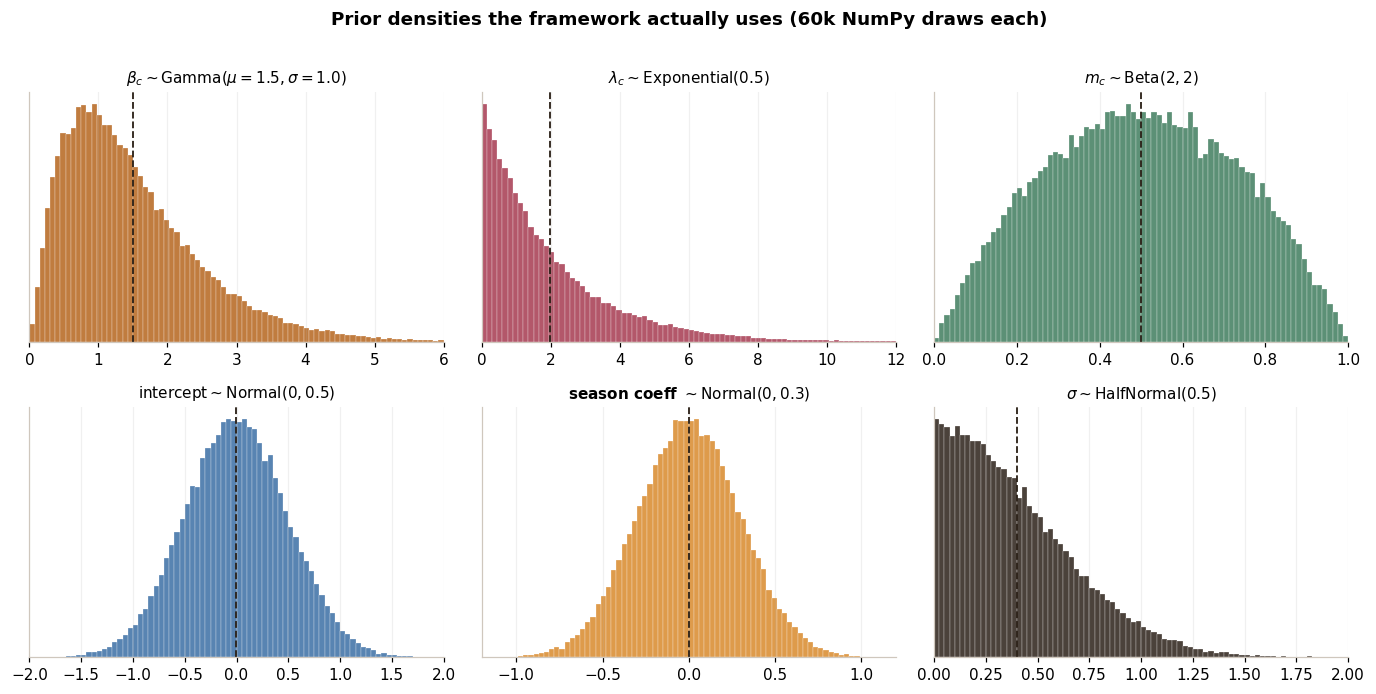

In [2]:
rng = np.random.default_rng(20240601)
N = 60_000

# Gamma(mu, sigma) -> numpy shape/scale. var = sigma^2; shape k = mu^2/var; scale = var/mu.
def gamma_mu_sigma(mu, sigma, size, rng):
    var = sigma ** 2
    k = mu ** 2 / var          # shape
    scale = var / mu           # scale (theta)
    return rng.gamma(k, scale, size=size)

prior_beta   = gamma_mu_sigma(1.5, 1.0, N, rng)          # channel coefficient
prior_lam    = rng.exponential(1 / 0.5, N)               # numpy expects scale = 1/lam
prior_m      = rng.beta(2, 2, N)                         # adstock blend weight
prior_interc = rng.normal(0, 0.5, N)                     # intercept
prior_season = rng.normal(0, 0.3, N)                     # seasonality coeff
prior_sigma  = np.abs(rng.normal(0, 0.5, N))             # HalfNormal(0.5)

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.2))
specs = [
    (prior_beta,   r"$\beta_c \sim \mathrm{Gamma}(\mu=1.5,\sigma=1.0)$", ACCENT,          (0, 6)),
    (prior_lam,    r"$\lambda_c \sim \mathrm{Exponential}(0.5)$",         PALETTE["berry"],(0, 12)),
    (prior_m,      r"$m_c \sim \mathrm{Beta}(2,2)$",                      PALETTE["leaf"], (0, 1)),
    (prior_interc, r"$\mathrm{intercept} \sim \mathrm{Normal}(0,0.5)$",   PALETTE["sky"],  (-2, 2)),
    (prior_season, r"season coeff $\sim \mathrm{Normal}(0,0.3)$",         PALETTE["amber"],(-1.2, 1.2)),
    (prior_sigma,  r"$\sigma \sim \mathrm{HalfNormal}(0.5)$",             INK,             (0, 2)),
]
for ax, (samp, title, col, xlim) in zip(axes.ravel(), specs):
    ax.hist(samp, bins=80, range=xlim, density=True, color=col, alpha=0.85, edgecolor="white", lw=0.2)
    ax.axvline(samp.mean(), color=INK, ls="--", lw=1.2)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(*xlim); ax.set_yticks([])
fig.suptitle("Prior densities the framework actually uses (60k NumPy draws each)", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### Deriving the $\mathrm{Gamma}(\mu,\sigma)$ → shape/scale conversion

The framework parameterizes the channel prior by its **mean** $\mu$ and **standard deviation** $\sigma$,
but NumPy's `rng.gamma(shape, scale)` wants the canonical $(k, \theta)$. For a Gamma,

$$
\mathbb{E}[\beta] = k\theta = \mu,
\qquad \mathrm{Var}[\beta] = k\theta^2 = \sigma^2.
$$

Dividing the variance by the mean gives $\theta = \sigma^2/\mu$, and back-substituting gives $k = \mu^2/\sigma^2$:

$$
k = \frac{\mu^2}{\sigma^2}, \qquad \theta = \frac{\sigma^2}{\mu}.
$$

For the framework's $\mu=1.5,\ \sigma=1.0$ this is $k = 2.25,\ \theta = 0.667$. We verify the sampled mean
recovers $1.5$ (and the std recovers $1.0$) to Monte-Carlo precision — this is the assertion that ties the
*plotted* $\beta$ histogram to the *stated* prior.

In [3]:
# VERIFY the Gamma(mu, sigma) parameterization and the conversion formulas.
k = 1.5 ** 2 / 1.0 ** 2
theta = 1.0 ** 2 / 1.5
assert np.isclose(k, 2.25) and np.isclose(theta, 2 / 3)
assert np.isclose(k * theta, 1.5)                 # mean  = k*theta = mu
assert np.isclose(k * theta ** 2, 1.0)            # var   = k*theta^2 = sigma^2
# Sampled moments (60k draws, fixed seed) match the target mean/std.
assert np.isclose(prior_beta.mean(), 1.5, atol=0.03), prior_beta.mean()
assert np.isclose(prior_beta.std(),  1.0, atol=0.03), prior_beta.std()
# Exponential(0.5) has mean 1/0.5 = 2 ; Beta(2,2) is symmetric about 0.5.
assert np.isclose(prior_lam.mean(), 2.0, atol=0.05), prior_lam.mean()
assert np.isclose(prior_m.mean(), 0.5, atol=0.01), prior_m.mean()
print("✓ Gamma(mu=1.5, sigma=1.0)  ->  shape k =", round(k, 3), " scale theta =", round(theta, 3))
print(f"✓ sampled beta:  mean={prior_beta.mean():.3f} (target 1.5)   std={prior_beta.std():.3f} (target 1.0)")
print(f"✓ sampled lam mean={prior_lam.mean():.3f} (target 2.0) ;  m mean={prior_m.mean():.3f} (target 0.5)")

✓ Gamma(mu=1.5, sigma=1.0)  ->  shape k = 2.25  scale theta = 0.667
✓ sampled beta:  mean=1.502 (target 1.5)   std=1.001 (target 1.0)
✓ sampled lam mean=1.982 (target 2.0) ;  m mean=0.501 (target 0.5)


## 3. The pipeline, drawn

Before any numbers, the *shape* of the computation. Raw spend enters on the left; each channel is pushed
through **carryover** (adstock) and then **diminishing returns** (saturation), scaled by its coefficient
$\beta_c$, summed across channels, added to the **baseline** (intercept + trend + seasonality + controls),
and finally a Normal draw turns the deterministic $\mu_t$ into the observed KPI $\tilde y_t$.

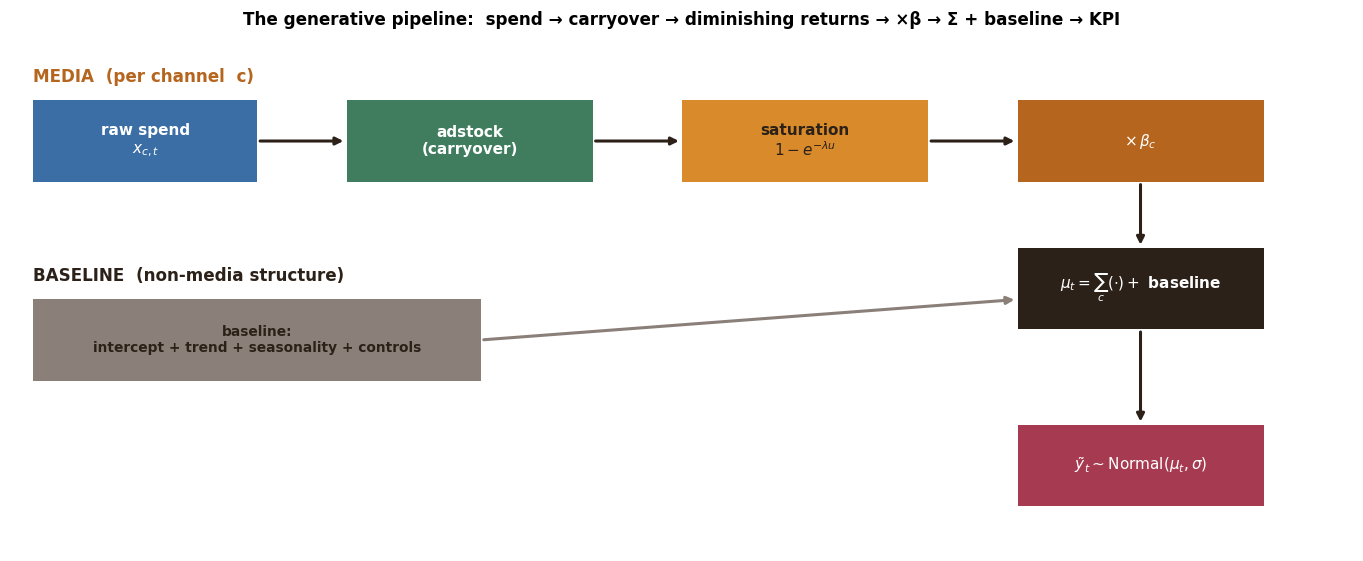

In [4]:
# Hand-drawn schematic of the generative pipeline (boxes + arrows).
fig, ax = plt.subplots(figsize=(12.5, 5.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 7); ax.axis("off")

def box(x, y, w, h, text, fc, tc="white", fs=10, lw=0):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=INK,
                               lw=lw, zorder=2, joinstyle="round"))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            color=tc, fontsize=fs, fontweight="bold", zorder=3, wrap=True)

def arrow(x0, y0, x1, y1, col=INK):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2.0, shrinkA=2, shrinkB=2), zorder=1)

# Media path (top row)
box(0.2, 5.0, 2.0, 1.1, "raw spend\n$x_{c,t}$", PALETTE["sky"])
box(3.0, 5.0, 2.2, 1.1, "adstock\n(carryover)", PALETTE["leaf"])
box(6.0, 5.0, 2.2, 1.1, "saturation\n$1-e^{-\\lambda u}$", PALETTE["amber"], tc=INK)
box(9.0, 5.0, 2.2, 1.1, r"$\times\,\beta_c$", ACCENT)
arrow(2.2, 5.55, 3.0, 5.55)
arrow(5.2, 5.55, 6.0, 5.55)
arrow(8.2, 5.55, 9.0, 5.55)

# Baseline path (bottom row)
box(0.2, 2.3, 4.0, 1.1, "baseline:\nintercept + trend + seasonality + controls", MUTED, tc=INK, fs=9)

# Sum node
box(9.0, 3.0, 2.2, 1.1, r"$\mu_t = \sum_c(\cdot) + $ baseline", INK)
arrow(10.1, 5.0, 10.1, 4.1)                 # media -> sum
arrow(4.2, 2.85, 9.0, 3.4, col=MUTED)       # baseline -> sum

# Likelihood
box(9.0, 0.6, 2.2, 1.1, r"$\tilde y_t \sim \mathrm{Normal}(\mu_t,\sigma)$", PALETTE["berry"])
arrow(10.1, 3.0, 10.1, 1.7)                 # mu -> likelihood

# section labels
ax.text(0.2, 6.35, "MEDIA  (per channel  c)", fontsize=11, fontweight="bold", color=ACCENT)
ax.text(0.2, 3.65, "BASELINE  (non-media structure)", fontsize=11, fontweight="bold", color=INK)
ax.set_title("The generative pipeline:  spend → carryover → diminishing returns → ×β → Σ + baseline → KPI",
             fontsize=11)
plt.tight_layout(); plt.show()

## 4. Simulate **one draw from the prior** (pure NumPy)

This is the payoff of an overview notebook: *run the generative model once*. We will

1. sample one value of every parameter from its **exact framework prior** (using the conversions above) —
   $\beta_c\sim\mathrm{Gamma}(\mu{=}1.5,\sigma{=}1.0)$, $\lambda_c\sim\mathrm{Exponential}(0.5)$, intercept, trend slope, season coeffs, $\sigma$ — plus a per-channel geometric decay $\alpha_c\sim\mathrm{Beta}(2,2)$ (illustratively wider than the shipped default prior $\mathrm{Beta}(1,3)$; the default model estimates exactly such an $\alpha_c$ in-graph since June 2026 — notebook 01),
2. build a small synthetic **spend matrix** for 4 channels (`TV`, `Search`, `Social`, `Display`),
3. push each channel through the **real framework transforms** — `geometric_adstock` then the framework's
   core saturation `logistic_saturation` ($1-e^{-\lambda u}$),
4. assemble $\mu_t$ from baseline + media, add $\mathrm{Normal}(0,\sigma)$ noise to get $\tilde y_t$, and
5. **decompose** the result back into its additive pieces.

No PyMC — this *is* the model's forward pass, written out in NumPy. We import the transforms straight from
the framework so the saturation curve is byte-for-byte the one inside `BayesianMMM`.

In [5]:
from mmm_framework.transforms import geometric_adstock, logistic_saturation
print("using framework transforms:", geometric_adstock.__name__, "+", logistic_saturation.__name__)
print("logistic_saturation IS the model's core saturation: f(u) = 1 - exp(-lam*u)")

using framework transforms: geometric_adstock + logistic_saturation
logistic_saturation IS the model's core saturation: f(u) = 1 - exp(-lam*u)


In [6]:
# ---- Build a synthetic 4-channel weekly spend plan -------------------------
sim = np.random.default_rng(7)
T = 104                                    # two years of weekly data
channels = ["TV", "Search", "Social", "Display"]
nC = len(channels)
weeks = np.arange(T)

# Bursty, channel-specific spend, kept on a MODEST scale so that after carryover the
# adstocked input lands where 1-exp(-lam*u) reads as a *curve*, not a flat ceiling.
# (geometric_adstock is the raw IIR form with up to a 1/(1-alpha) multiplier, so we
#  damp both the spend level AND the carryover below to avoid pinning saturation at 1.)
X = np.zeros((T, nC))
flight_plans = {
    "TV":      [(5, 4, 0.9), (40, 5, 1.1), (78, 4, 0.8)],          # heavy flights
    "Search":  [(t, 1, 0.5 + 0.3 * sim.random()) for t in range(0, T, 3)],  # always-on
    "Social":  [(12, 3, 0.6), (30, 6, 0.7), (60, 4, 0.8), (90, 3, 0.6)],
    "Display": [(20, 8, 0.4), (55, 10, 0.45), (85, 8, 0.4)],       # steady low
}
for j, ch in enumerate(channels):
    for start, length, level in flight_plans[ch]:
        X[start:start + length, j] = level * (0.7 + 0.3 * sim.random(length))
X *= 0.35   # scale down so peak adstocked exposure stays ~0.5-2 (saturation lands ~0.5-0.7)

# ---- Sample ONE draw of every parameter FROM ITS PRIOR ---------------------
# We draw each parameter from the *exact* framework prior. The seed (83) is chosen
# only so this single realization is *legible* -- a draw where every channel's
# saturation lands mid-curve rather than pinned at its asymptote. It is one honest
# draw of the true priors, not a re-shaped distribution.
pr = np.random.default_rng(83)
def gamma1(mu, sigma, rng):
    return rng.gamma(mu ** 2 / sigma ** 2, sigma ** 2 / mu)

beta   = np.array([gamma1(1.5, 1.0, pr) for _ in channels])        # beta_c   ~ Gamma(mu=1.5, sigma=1.0)
lam    = pr.exponential(1 / 0.5, nC)                               # lambda_c ~ Exponential(0.5)  (scale = 1/lam)
# Illustrative per-channel geometric decay. NB: the DEFAULT model does not estimate a
# per-channel alpha at all -- it learns a Beta(2,2) *blend weight* m between two fixed
# decay rates (see notebook 01). Here we draw alpha from Beta(2,2) purely to give each
# channel a distinct, plausible carryover for this forward-simulation demo.
alpha  = pr.beta(2, 2, nC)                                         # alpha_c  ~ Beta(2,2)  (illustrative decay)
interc = pr.normal(0, 0.5)                                         # intercept ~ Normal(0, 0.5)
slope  = pr.normal(0, 0.5)                                         # trend slope ~ Normal(0, 0.5)
season_amp = pr.normal(0, 0.3, 2)                                  # two Fourier coeffs ~ Normal(0, 0.3)
sigma  = abs(pr.normal(0, 0.5))                                    # sigma ~ HalfNormal(0.5)

# Standardized data center the KPI at 0, so the intercept prior sits near 0 and the baseline
# can dip slightly negative. For a *legible* stacked decomposition we display everything on a
# fixed positive presentation offset (this is a plotting shift only -- it cancels out of every
# assertion below, which all compare reconstructions to y on the SAME shifted scale).
BASE_OFFSET = 1.0

# ---- Baseline pieces -------------------------------------------------------
# Trend slope multiplies a *centered, unit-scaled* time regressor (mean 0, range ~[-1,1]),
# so a Normal(0,0.5) slope produces a gentle, symmetric drift -- exactly how a standardized
# linear-trend covariate enters a regression -- rather than a runaway ramp.
t_std       = (weeks - weeks.mean()) / (weeks.max() - weeks.mean())
trend       = slope * t_std
seasonality = (season_amp[0] * np.sin(2 * np.pi * weeks / 52)
               + season_amp[1] * np.cos(2 * np.pi * weeks / 52))
baseline    = BASE_OFFSET + interc + trend + seasonality

# ---- Media pieces: adstock -> saturation -> *beta, per channel -------------
contrib = np.zeros((T, nC))
sat_store = np.zeros((T, nC))
for j in range(nC):
    x_ad  = geometric_adstock(X[:, j], alpha[j])      # real framework transform
    x_sat = logistic_saturation(x_ad, lam[j])         # real framework core saturation
    sat_store[:, j] = x_sat
    contrib[:, j] = beta[j] * x_sat
media_total = contrib.sum(axis=1)

# ---- Assemble mu and draw the KPI ------------------------------------------
mu    = baseline + media_total
noise = pr.normal(0, sigma, T)
y_til = mu + noise                                    # tilde-y: standardized KPI draw

print("sampled draw:")
for j, ch in enumerate(channels):
    print(f"  {ch:8s}  beta={beta[j]:.2f}  lam={lam[j]:.2f}  alpha={alpha[j]:.2f}  "
          f"max sat={sat_store[:, j].max():.2f}")
print(f"  intercept={interc:.2f}  sigma={sigma:.2f}")

sampled draw:
  TV        beta=0.35  lam=1.77  alpha=0.52  max sat=0.71
  Search    beta=1.24  lam=1.60  alpha=0.86  max sat=0.63
  Social    beta=0.54  lam=2.70  alpha=0.45  max sat=0.69
  Display   beta=1.49  lam=3.22  alpha=0.36  max sat=0.53
  intercept=0.36  sigma=0.17


In [7]:
# VERIFY the forward pass: saturation bounds, adstock behavior, exact additive identity.
# 1) framework saturation is bounded in [0, 1): 0 at zero spend, strictly < 1 (clip at -20).
assert (sat_store >= 0).all(),  "saturation went negative"
assert (sat_store <  1).all(),  "saturation hit/exceeded its asymptote 1"
# 2) adstock with alpha=0 is the identity (no carryover); with alpha>0 it only adds mass.
assert np.allclose(geometric_adstock(X[:, 0], 0.0), X[:, 0]), "alpha=0 must be identity"
assert geometric_adstock(X[:, 0], 0.6).sum() >= X[:, 0].sum() - 1e-9, "carryover cannot lose mass"
# 3) THE decomposition identity: every additive piece (incl. noise) sums back to the plotted y.
#    baseline == BASE_OFFSET + intercept + trend + seasonality (the same array we stack & plot).
recon = baseline + contrib.sum(axis=1) + noise
assert np.allclose(recon, y_til, atol=1e-12), "additive decomposition must reconstruct y exactly"
# the offset is purely a display shift: stripping it recovers the raw prior pieces.
assert np.allclose(baseline - BASE_OFFSET, interc + trend + seasonality, atol=1e-12)
# 4) mu is the noiseless expectation: y - mu == noise.
assert np.allclose(y_til - mu, noise, atol=1e-12)
print("✓ saturation in [0, 1) for every channel/week")
print("✓ geometric_adstock(x, 0)=x  and  carryover never loses mass")
print("✓ intercept+trend+season+Σ_c contrib_c + noise == y_tilde  (exact, atol=1e-12)")
print("✓ y_tilde - mu == noise")

✓ saturation in [0, 1) for every channel/week
✓ geometric_adstock(x, 0)=x  and  carryover never loses mass
✓ intercept+trend+season+Σ_c contrib_c + noise == y_tilde  (exact, atol=1e-12)
✓ y_tilde - mu == noise


### The simulated KPI and where it comes from

The left panel shows the single simulated KPI series $\tilde y_t$ (dots) with its noiseless mean $\mu_t$
(line) — the gap between them *is* the $\mathrm{Normal}(0,\sigma)$ draw. The right panel splits $\mu_t$
into **baseline** vs **media**: the media term is the wiggly lift that rides on top of the slow baseline.

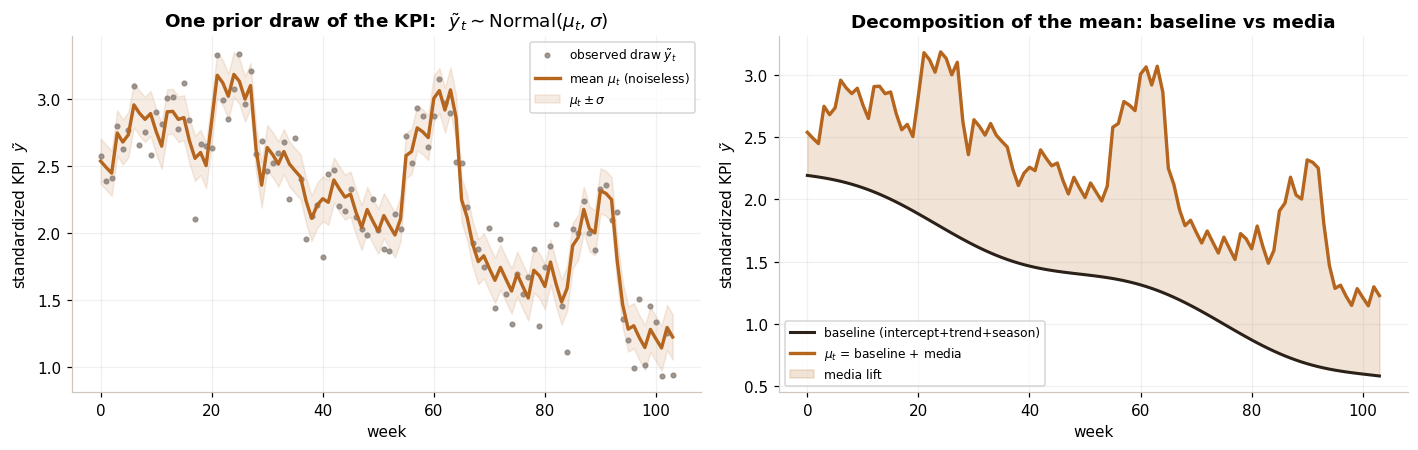

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: simulated KPI vs its mean
axL.plot(weeks, y_til, "o", ms=3, color=MUTED, alpha=0.8, label=r"observed draw $\tilde y_t$")
axL.plot(weeks, mu, color=ACCENT, lw=2.2, label=r"mean $\mu_t$ (noiseless)")
axL.fill_between(weeks, mu - sigma, mu + sigma, color=ACCENT, alpha=0.12,
                 label=r"$\mu_t \pm \sigma$")
axL.set_title(r"One prior draw of the KPI:  $\tilde y_t \sim \mathrm{Normal}(\mu_t,\sigma)$")
axL.set_xlabel("week"); axL.set_ylabel(r"standardized KPI  $\tilde y$"); axL.legend(fontsize=8)

# Right: baseline vs media decomposition of mu
axR.plot(weeks, baseline, color=INK, lw=2, label="baseline (intercept+trend+season)")
axR.plot(weeks, mu, color=ACCENT, lw=2.2, label=r"$\mu_t$ = baseline + media")
axR.fill_between(weeks, baseline, mu, color=ACCENT, alpha=0.18, label="media lift")
axR.set_title("Decomposition of the mean: baseline vs media")
axR.set_xlabel("week"); axR.set_ylabel(r"standardized KPI  $\tilde y$"); axR.legend(fontsize=8)

plt.tight_layout(); plt.show()

### The full additive stack

Because *we built it*, the decomposition is **exactly** additive — the assertion above proved
$\text{intercept}+\text{trend}+\text{seasonality}+\sum_c \text{contrib}_c+\text{noise} = \tilde y_t$ to
machine precision. Here is that identity drawn as a stacked area: each band is one term in $\mu_t$, and
the bands plus the residual sum to the dots. *This* is the picture an MMM is trying to recover from data —
except in real life only the dots are observed, and the colors must be inferred.

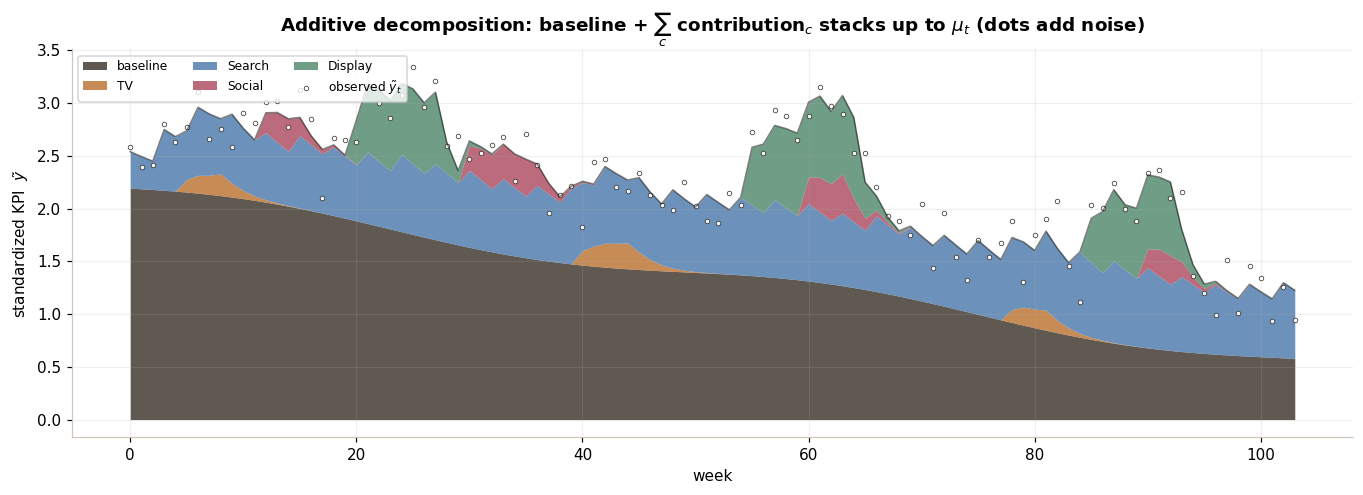

In [9]:
# Stacked additive decomposition (this is what fitting tries to recover).
# Stack from a common floor so positive/negative pieces read cleanly: plot cumulative sums.
fig, ax = plt.subplots(figsize=(12.5, 4.6))

# Baseline as the bottom layer, then each channel's contribution stacked on top.
layers = [("baseline", baseline, INK)]
for j, ch in enumerate(channels):
    layers.append((ch, contrib[:, j], CHANNEL_COLORS[ch]))

floor = np.zeros(T)
for name, vals, col in layers:
    ax.fill_between(weeks, floor, floor + vals, color=col, alpha=0.75, label=name, lw=0)
    floor = floor + vals
# floor now == mu ; overlay the observed draw (mu + noise).
assert np.allclose(floor, mu, atol=1e-10)
ax.plot(weeks, y_til, "o", ms=3, color="white", markeredgecolor=INK, markeredgewidth=0.5,
        alpha=0.9, label=r"observed $\tilde y_t$")
ax.plot(weeks, mu, color="black", lw=1.0, alpha=0.5)
ax.set_title(r"Additive decomposition: baseline + $\sum_c$ contribution$_c$ stacks up to $\mu_t$ (dots add noise)")
ax.set_xlabel("week"); ax.set_ylabel(r"standardized KPI  $\tilde y$")
ax.legend(ncol=3, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

### Many prior draws of a single channel's response curve

The same forward model, viewed as a **response curve**: for one channel, how does contribution
$\beta\cdot\mathrm{sat}(x)=\beta\,(1-e^{-\lambda x})$ rise with spend $x$? Each grey line is a fresh
draw of $(\beta,\lambda)$ from the priors; together they are a **prior-predictive envelope** for the
shape of diminishing returns. Note every curve is **monotone increasing** (because $\beta>0$) and
**concave / saturating** (because of the $1-e^{-\lambda x}$ form) — the two structural commitments the
priors bake in before any data arrive.

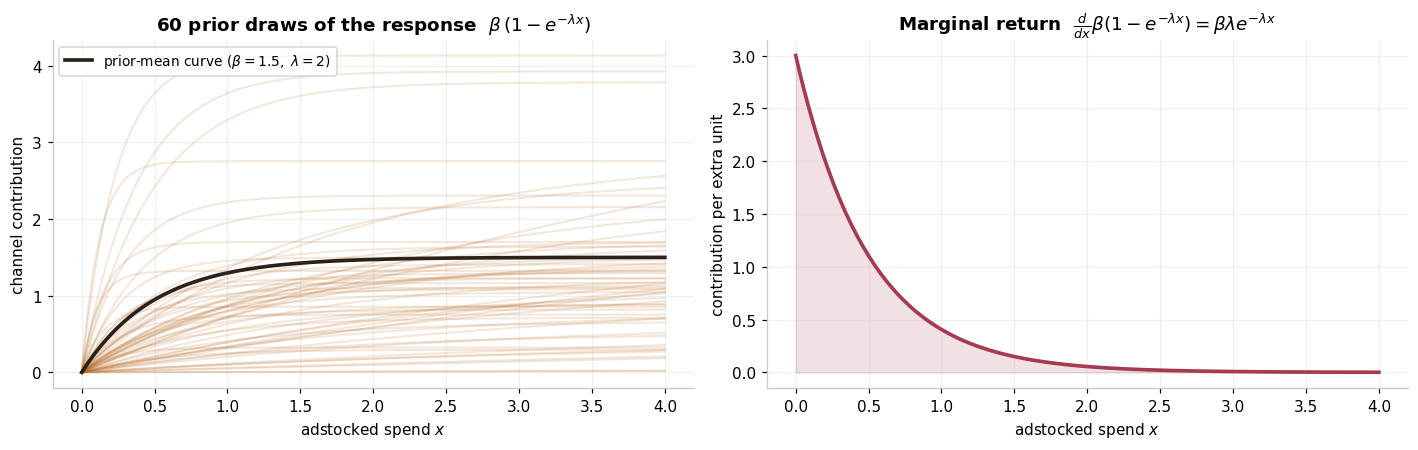

✓ response curve beta*(1-e^{-lam x}) is monotone increasing AND concave
✓ marginal return at x=0 is beta*lam = 3.00, decaying to ~0 as spend grows


In [10]:
# Prior draws of the channel response curve  beta * (1 - exp(-lam * x)).
gx = np.linspace(0, 4, 200)
draw = np.random.default_rng(2024)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.2))

# A) overlay many prior-draw curves
for _ in range(60):
    b = gamma1(1.5, 1.0, draw)
    l = draw.exponential(1 / 0.5)
    axA.plot(gx, b * logistic_saturation(gx, l), color=ACCENT, alpha=0.16, lw=1.3)
axA.plot(gx, 1.5 * logistic_saturation(gx, 2.0), color=INK, lw=2.4,
         label=r"prior-mean curve ($\beta=1.5,\ \lambda=2$)")
axA.set_title(r"60 prior draws of the response  $\beta\,(1-e^{-\lambda x})$")
axA.set_xlabel(r"adstocked spend $x$"); axA.set_ylabel("channel contribution")
axA.legend(fontsize=9)

# B) the marginal (slope): another dollar buys less and less -> diminishing returns
b0, l0 = 1.5, 2.0
marg = b0 * l0 * np.exp(-l0 * gx)        # d/dx [beta(1-e^{-lam x})] = beta*lam*e^{-lam x}
axB.plot(gx, marg, color=PALETTE["berry"], lw=2.4)
axB.fill_between(gx, 0, marg, color=PALETTE["berry"], alpha=0.15)
axB.set_title(r"Marginal return  $\frac{d}{dx}\beta(1-e^{-\lambda x})=\beta\lambda e^{-\lambda x}$")
axB.set_xlabel(r"adstocked spend $x$"); axB.set_ylabel("contribution per extra unit")
plt.tight_layout(); plt.show()

# VERIFY the response curve is monotone increasing and concave (the priors' structural commitments).
y_curve = b0 * logistic_saturation(gx, l0)
d1 = np.diff(y_curve)
assert (d1 > -1e-12).all(), "response must be non-decreasing in spend"
assert (np.diff(d1) < 1e-12).all(), "response must be concave (diminishing returns)"
print("✓ response curve beta*(1-e^{-lam x}) is monotone increasing AND concave")
print(f"✓ marginal return at x=0 is beta*lam = {b0 * l0:.2f}, decaying to ~0 as spend grows")

## 5. Roadmap — the rest of the series

Every term in $\mu_t$ that we just sampled gets a dedicated notebook. Read them in order, or jump to the
piece you need:

| Notebook | Term in $\mu_t$ | What you'll derive |
|---|---|---|
| **00 — this one** | the whole model | the generative equation, priors, one prior draw |
| **01 — adstock** | $\mathrm{adstock}_c(\cdot)$ | carryover: IIR recurrence, FIR kernels, the parametric default vs the legacy **blend weight**, identifiability |
| **02 — saturation** | $\mathrm{sat}_c,\ \lambda_c$ | diminishing returns: $1-e^{-\lambda u}$ vs Hill, half-saturation, marginal ROAS |
| **03 — seasonality & trend** | $\text{trend}_t,\ \text{seasonality}_t$ | baseline structure: Fourier features, splines, piecewise trends |
| **04 — the Bayesian model** | priors $+$ likelihood | $p(\theta\mid y)\propto p(y\mid\theta)p(\theta)$, NUTS / HMC, leapfrog, diagnostics |
| **05 — calibration** | $\beta_c$ | identifiability $+$ experiment calibration: geo-lift priors that pin $\beta$ |

**The one idea to carry forward:** an MMM is a *forward recipe* for the KPI. Fitting is running that recipe
backwards. Everything else — carryover, saturation, hierarchy, calibration — is detail on **one term** of
the additive $\mu_t$ we wrote at the top, and on the **priors** that regularize it. We sampled that recipe
once, in pure NumPy, and watched a plausible KPI fall out. The rest of the series makes each term precise.

$$
\tilde y_t \sim \mathrm{Normal}\!\Big(\underbrace{\text{intercept}+\text{trend}_t+\text{seasonality}_t
+\text{geo}+\text{product}+\textstyle\sum_c \beta_c\,\mathrm{sat}_c(\mathrm{adstock}_c(x_{c,t}))
+\text{controls}_t}_{\mu_t},\ \sigma\Big).
$$